<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/7_housing_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🟩 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 🟩 2. Load Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv")

df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🟩 3. Define Features & Target

In [3]:
target = "log_saleprice"
df[target] = np.log(df["saleprice"])

X = df.drop(columns=[target])
y = df[target]

## 🟩 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2340, 80)
Test shape: (585, 80)


## 🟩 5. Preprocessing (CRITICAL STEP)

In [5]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

## 🟩 6. Define Models (Best Tuned)

In [6]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ))
])

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

## 🟩 7. Cross Validation Function

In [7]:
def evaluate_cv(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse = np.sqrt(-scores)

    print("RMSE Scores:", rmse)
    print("Mean RMSE:", rmse.mean())
    print("Std RMSE:", rmse.std())

    return rmse

## 8. Cross Validation Results

In [8]:
print("🔹 Random Forest CV:")
rf_cv = evaluate_cv(rf_pipeline, X, y)

print("\n🔹 Gradient Boosting CV:")
gb_cv = evaluate_cv(gb_pipeline, X, y)

🔹 Random Forest CV:
RMSE Scores: [0.03857149 0.00513091 0.03749689 0.00378107 0.0089697 ]
Mean RMSE: 0.018790013105736057
Std RMSE: 0.01580842910811031

🔹 Gradient Boosting CV:
RMSE Scores: [0.02783288 0.00418222 0.0202691  0.00250332 0.00278291]
Mean RMSE: 0.011514085117294922
Std RMSE: 0.010527457066633368


## 9. Train Final Models on Training Data

In [9]:
rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['ms_subclass', 'lot_frontage', 'lot_area', 'overall_qual',
       'overall_cond', 'year_built', 'year_remodadd', 'mas_vnr_area',
       'bsmtfin_sf_1', 'bsmtfin_sf_2', 'bsmt_unf_sf', 'total_bsmt_sf',
       '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf', 'gr_liv_area',
       'bsmt_full_bath', 'bsmt_hal...
       'bsmtfin_type_1', 'bsmtfin_type_2', 'heating', 'heating_qc',
       'central_air', 'electrical', 'kitchen_qual', 'functional',
       'fireplace_qu', 'garage_type', 'garage_finish', 'garage_qual',
       'garage_cond', 'paved_drive', 'pool_qc', 'fence', 'misc_feature',
       'sale_type', 'sale_condition'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

## 10. Predictions on Test Set

In [10]:
rf_preds = rf_pipeline.predict(X_test)
gb_preds = gb_pipeline.predict(X_test)

## 11. Evaluation Function

In [11]:
def evaluate_test(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance:")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2

## 12. Test Set Evaluation

In [12]:
rf_test = evaluate_test(y_test, rf_preds, "Random Forest")
gb_test = evaluate_test(y_test, gb_preds, "Gradient Boosting")


Random Forest Performance:
RMSE: 0.010132356722007194
MAE : 0.001705698948990983
R2  : 0.9994059353703678

Gradient Boosting Performance:
RMSE: 0.002983055529356198
MAE : 0.001630248013849503
R2  : 0.999948508513628


## 13. Model Comparison Table

In [13]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "RMSE": [rf_test[0], gb_test[0]],
    "MAE": [rf_test[1], gb_test[1]],
    "R2": [rf_test[2], gb_test[2]]
})

results

,Model,RMSE,MAE,R2
0,Random Forest,0.010132,0.001706,0.999406
1,Gradient Boosting,0.002983,0.001630,0.999949


## 14. Visualization (VERY IMPORTANT FOR PORTFOLIO)
📊 CV Comparison

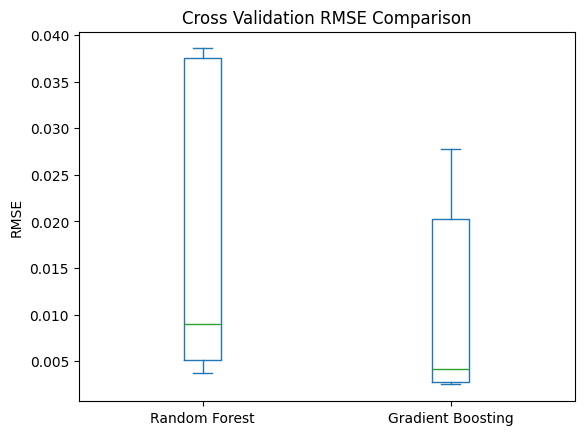

In [14]:
cv_results = pd.DataFrame({
    "Random Forest": rf_cv,
    "Gradient Boosting": gb_cv
})

cv_results.plot(kind='box', title="Cross Validation RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

### 📈 Prediction vs Actual

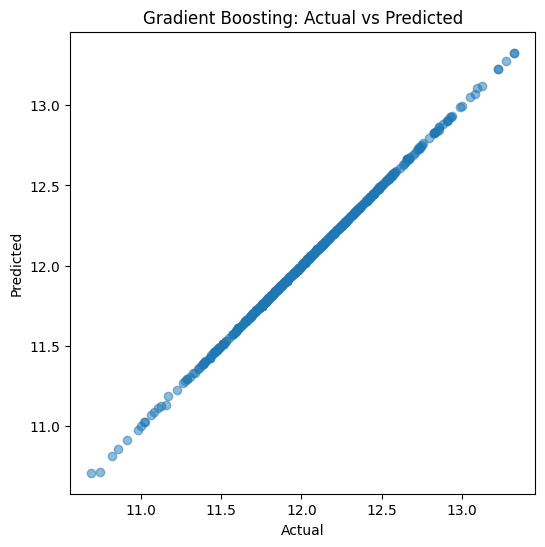

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, gb_preds, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.show()

### 📉 Residual Plot

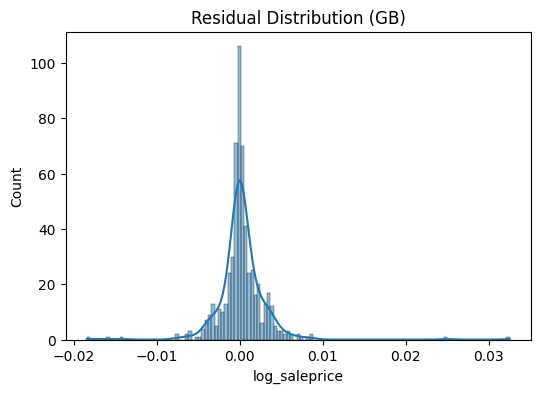

In [16]:
residuals = y_test - gb_preds

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (GB)")
plt.show()

## 15. Final Conclusion
## Final Model Evaluation Summary

- Gradient Boosting performed better than Random Forest based on RMSE and R².
- Cross-validation results confirm model stability.
- Residuals show near-normal distribution, indicating good model fit.

### Final Selected Model:
👉 Gradient Boosting Regressor